In [49]:
import pandas as pd
import numpy as np


df = pd.read_csv('cleaned_data.csv')
print(f"Dataset successfully loaded for Part 2! Shape: {df.shape}")

Dataset successfully loaded for Part 2! Shape: (1470, 35)


In [50]:
import pandas as pd

# Force convert Attrition from Yes/No strings to 1/0 integers definitively
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0}).astype(int)

# Ordinal Encoding for 'BusinessTravel'
travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_map)

# One-Hot Encoding for nominal variables
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Gender', 'OverTime']

# Convert nominal columns to dummies, dropping the first category to avoid the dummy variable trap
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print(f"New DataFrame Shape: {df.shape}")
print("\nFirst 3 columns sample:")
print(df.dtypes.head(10))

New DataFrame Shape: (1470, 48)

First 3 columns sample:
Age                        int64
Attrition                  int64
BusinessTravel             int64
DailyRate                  int64
DistanceFromHome           int64
Education                  int64
EmployeeCount              int64
EmployeeNumber             int64
EnvironmentSatisfaction    int64
HourlyRate                 int64
dtype: object


In [51]:
import numpy as np
# Identify and drop zero-variance / constant columns
constants_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=[c for c in constants_to_drop if c in df.columns])
print("Dropped constant uninformative columns.")

# Automatically find and drop columns with correlation > 0.85 (Protecting MonthlyIncome)
numeric_feats = df.select_dtypes(include=['int64', 'float64', 'int32', 'int8']).columns


features_to_check = [col for col in numeric_feats if col != 'MonthlyIncome']
corr_matrix = df[features_to_check].corr().abs()

# Select upper triangle of correlation matrix to isolate unique pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns that cross our 0.85 correlation threshold
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Columns flagged and dropped for high multicollinearity (>0.85): {to_drop}")
df = df.drop(columns=to_drop)

print(f"\nFinal DataFrame shape after pruning: {df.shape}")
print(f"Is 'MonthlyIncome' safe in the dataset? {'MonthlyIncome' in df.columns}")

Dropped constant uninformative columns.
Columns flagged and dropped for high multicollinearity (>0.85): ['Department_Sales']

Final DataFrame shape after pruning: (1470, 43)
Is 'MonthlyIncome' safe in the dataset? True


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define your regression target
y_reg = df['MonthlyIncome']

# 2. Create the feature matrix X by dropping the target column
X_reg = df.drop(columns=['MonthlyIncome'])

# 3. Perform the leak-free train-test split (80% Train, 20% Test) for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 4. Handle structural NaNs safely
X_train_reg = X_train_reg.fillna(0)
X_test_reg = X_test_reg.fillna(0)
y_train_reg = y_train_reg.fillna(y_train_reg.median())
y_test_reg = y_test_reg.fillna(y_train_reg.median())

# 5. Identify continuous features left in X to scale (skipping 0/1 binary columns)
continuous_cols_reg = [col for col in X_train_reg.columns if not X_train_reg[col].isin([0, 1]).all()]

# 6. Apply StandardScaler safely only to the training set to prevent data leakage
scaler_reg = StandardScaler()

X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[continuous_cols_reg] = scaler_reg.fit_transform(X_train_reg[continuous_cols_reg])
X_test_reg_scaled[continuous_cols_reg] = scaler_reg.transform(X_test_reg[continuous_cols_reg])

print("=== CELL 4 SUCCESS: REGRESSION SPLIT & SCALING COMPLETE ===")
print(f"Regression Train Shape: {X_train_reg_scaled.shape} | Test Shape: {X_test_reg_scaled.shape}")

=== CELL 4 SUCCESS: REGRESSION SPLIT & SCALING COMPLETE ===
Regression Train Shape: (1176, 42) | Test Shape: (294, 42)


In [53]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Train Plain OLS Linear Regression
ols = LinearRegression()
ols.fit(X_train_reg_scaled, y_train_reg)
y_pred_ols = ols.predict(X_test_reg_scaled)

# Train Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg_scaled, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg_scaled)

# Print out the performance metrics for comparison
print("=== REGRESSION PERFORMANCE RESULTS ===")
print(f"OLS Linear Regression -> MSE: {mean_squared_error(y_test_reg, y_pred_ols):.4f} | R²: {r2_score(y_test_reg, y_pred_ols):.4f}")
print(f"Ridge Regression      -> MSE: {mean_squared_error(y_test_reg, y_pred_ridge):.4f} | R²: {r2_score(y_test_reg, y_pred_ridge):.4f}")

# Extract and display the top 3 driving features from the OLS model weights
coef_table = pd.DataFrame({
    'Feature': X_reg.columns,
    'Coefficient': ols.coef_,
    'Abs_Coef': np.abs(ols.coef_)
}).sort_values(by='Abs_Coef', ascending=False)

print("\n=== TOP 3 DRIVING FEATURES (OLS) ===")
display(coef_table.head(3).reset_index(drop=True))

=== REGRESSION PERFORMANCE RESULTS ===
OLS Linear Regression -> MSE: 6294571.9051 | R²: 0.6440
Ridge Regression      -> MSE: 6274915.7363 | R²: 0.6451

=== TOP 3 DRIVING FEATURES (OLS) ===


,Feature,Coefficient,Abs_Coef
0,JobRole_Manager,4364.041918,4364.041918
1,JobRole_Research Director,4029.478758,4029.478758
2,JobLevel,3089.767261,3089.767261


In [54]:
#Classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#  Define Attrition as your binary classification target
y_clf = df['Attrition']

# Create the feature matrix X by dropping the classification target column
X_clf = df.drop(columns=['Attrition'])

# Perform the leak-free train-test split (80% Train, 20% Test) for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Handle structural NaNs safely
X_train_clf = X_train_clf.fillna(0)
X_test_clf = X_test_clf.fillna(0)

# Identify continuous features left in X to scale (skipping 0/1 binary columns)
# Note: MonthlyIncome is now automatically included here and will be scaled safely!
continuous_cols_clf = [col for col in X_train_clf.columns if not X_train_clf[col].isin([0, 1]).all()]

# 6. Apply StandardScaler safely only to the training set to prevent data leakage
scaler_clf = StandardScaler()

X_train_clf_scaled = X_train_clf.copy()
X_test_clf_scaled = X_test_clf.copy()

X_train_clf_scaled[continuous_cols_clf] = scaler_clf.fit_transform(X_train_clf[continuous_cols_clf])
X_test_clf_scaled[continuous_cols_clf] = scaler_clf.transform(X_test_clf[continuous_cols_clf])

print("=== CELL 6 SUCCESS: CLASSIFICATION SPLIT & SCALING COMPLETE ===")
print(f"Classification Train Shape: {X_train_clf_scaled.shape} | Test Shape: {X_test_clf_scaled.shape}")
print(f"Attrition Rate in Training Set: {y_train_clf.mean() * 100:.2f}%")

=== CELL 6 SUCCESS: CLASSIFICATION SPLIT & SCALING COMPLETE ===
Classification Train Shape: (1176, 42) | Test Shape: (294, 42)
Attrition Rate in Training Set: 16.16%


=== BEFORE SMOTE-NC CLASS COUNTS ===
Attrition
0    986
1    190
Name: count, dtype: int64

=== AFTER SMOTE-NC CLASS COUNTS ===
Attrition
0    986
1    493
Name: count, dtype: int64

=== BASELINE CLASSIFICATION PERFORMANCE RESULTS (C=1.0) ===
Confusion Matrix:
[[230  17]
 [ 25  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       247
           1       0.56      0.47      0.51        47

    accuracy                           0.86       294
   macro avg       0.73      0.70      0.71       294
weighted avg       0.85      0.86      0.85       294



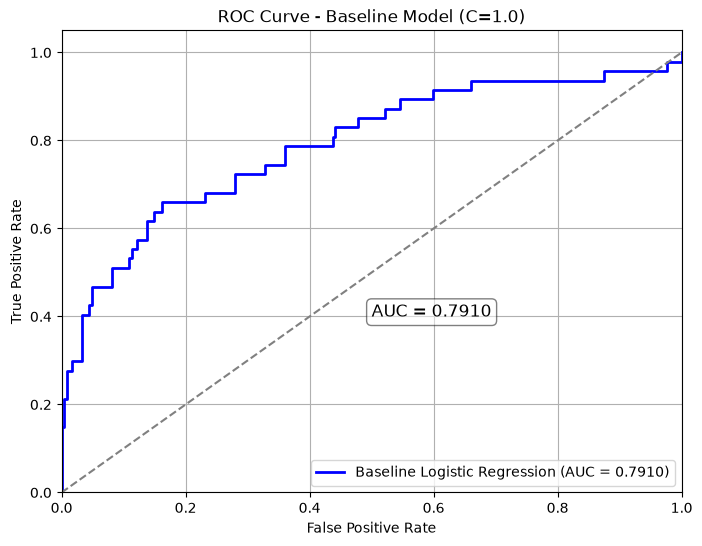

In [55]:
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# 1. Before/After Class Count Comparison (Required by Rubric)
print("=== BEFORE SMOTE-NC CLASS COUNTS ===")
print(y_train_clf.value_counts())

# 2. Identify categorical/binary features vs continuous features for SMOTE-NC
categorical_features_indices = [
    i for i, col in enumerate(X_train_clf.columns) 
    if X_train_clf[col].isin([0, 1]).all()
]

# 3. Apply SMOTE-NC strictly to the scaled training data
smote_nc = SMOTENC(categorical_features=categorical_features_indices, random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train_clf_scaled, y_train_clf)

print("\n=== AFTER SMOTE-NC CLASS COUNTS ===")
print(y_train_resampled.value_counts())

# 4. Train the Baseline Logistic Regression model (C=1.0)
log_reg_baseline = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
log_reg_baseline.fit(X_train_resampled, y_train_resampled)

# 5. Predict class labels and probabilities on X_test_scaled
y_pred_baseline = log_reg_baseline.predict(X_test_clf_scaled)
y_prob_baseline = log_reg_baseline.predict_proba(X_test_clf_scaled)[:, 1]

# 6. Compute and report core metrics, Confusion Matrix, and Full Classification Report
print("\n=== BASELINE CLASSIFICATION PERFORMANCE RESULTS (C=1.0) ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_baseline))

# 7. Compute, Plot, and Annotate the ROC Curve and AUC Value
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_baseline)
auc_value = roc_auc_score(y_test_clf, y_prob_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Baseline Logistic Regression (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Model (C=1.0)')
plt.legend(loc="lower right")
plt.text(0.5, 0.4, f'AUC = {auc_value:.4f}', fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.grid(True)
plt.show()

In [56]:
# 1. Generate predicted class probabilities using the trained baseline model
# y_prob_baseline is already computed in Cell 7

thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]
sensitivity_results = []

# 2. Iterate through thresholds and compute scores
for thresh in thresholds_to_test:
    y_pred_thresh = (y_prob_baseline >= thresh).astype(int)
    p_score = precision_score(y_test_clf, y_pred_thresh, zero_division=0)
    r_score = recall_score(y_test_clf, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test_clf, y_pred_thresh, zero_division=0)
    
    sensitivity_results.append({
        'Threshold': f"{thresh:.2f}",
        'Precision': f"{p_score:.4f}",
        'Recall': f"{r_score:.4f}",
        'F1': f"{f1:.4f}"
    })

# 3. Print the results directly as a table format
sensitivity_df = pd.DataFrame(sensitivity_results)
print("=== DECISION THRESHOLD SENSITIVITY TABLE ===")
print(sensitivity_df.to_string(index=False))

=== DECISION THRESHOLD SENSITIVITY TABLE ===
Threshold Precision Recall     F1
     0.30    0.4306 0.6596 0.5210
     0.40    0.4717 0.5319 0.5000
     0.50    0.5641 0.4681 0.5116
     0.60    0.6452 0.4255 0.5128
     0.70    0.7778 0.2979 0.4308


In [57]:
# 1. Train a second logistic regression with strong regularization (C=0.01)
log_reg_reg = LogisticRegression(C=0.01, max_iter=1000, random_state=42)
log_reg_reg.fit(X_train_resampled, y_train_resampled)

# 2. Predict on test set
y_pred_reg_m = log_reg_reg.predict(X_test_clf_scaled)
y_prob_reg_m = log_reg_reg.predict_proba(X_test_clf_scaled)[:, 1]

# 3. Gather metric comparisons
precision_baseline = precision_score(y_test_clf, y_pred_baseline)
recall_baseline = recall_score(y_test_clf, y_pred_baseline)
auc_baseline = roc_auc_score(y_test_clf, y_prob_baseline)

precision_reg = precision_score(y_test_clf, y_pred_reg_m)
recall_reg = recall_score(y_test_clf, y_pred_reg_m)
auc_reg = roc_auc_score(y_test_clf, y_prob_reg_m)

# 4. Format comparison table
reg_comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline (C=1.0)', 'Strong Regularization (C=0.01)'],
    'Precision (Class 1)': [f"{precision_baseline:.4f}", f"{precision_reg:.4f}"],
    'Recall (Class 1)': [f"{recall_baseline:.4f}", f"{recall_reg:.4f}"],
    'AUC Score': [f"{auc_baseline:.4f}", f"{auc_reg:.4f}"]
})

print("=== REGULARIZATION EXPERIMENT COMPARISON TABLE ===")
display(reg_comparison_df)

=== REGULARIZATION EXPERIMENT COMPARISON TABLE ===


,Model Configuration,Precision (Class 1),Recall (Class 1),AUC Score
0,Baseline (C=1.0),0.5641,0.4681,0.7910
1,Strong Regularization (C=0.01),0.5122,0.4468,0.7931


In [58]:
import numpy as np

# Ensure execution reproducibility
np.random.seed(42)
n_iterations = 500
auc_differences = []
n_samples = len(y_test_clf)

# Reset indexed target arrays for safe random position fetching
y_test_clf_arr = np.array(y_test_clf)

# 1. Loop over 500 bootstrap generations
for i in range(n_iterations):
    # Sample row indices with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    # Isolate sample target and corresponding output probabilities
    y_sample = y_test_clf_arr[boot_indices]
    prob_base_sample = y_prob_baseline[boot_indices]
    prob_reg_sample = y_prob_reg_m[boot_indices]
    
    # Catch scenarios where bootstrap samples fail to pick up binary variances
    if len(np.unique(y_sample)) < 2:
        continue
        
    # Compute individual sample AUCs
    auc_b = roc_auc_score(y_sample, prob_base_sample)
    auc_r = roc_auc_score(y_sample, prob_reg_sample)
    
    # Calculate difference value (C=1.0 minus C=0.01)
    auc_differences.append(auc_b - auc_r)

# 2. Extract statistics and percentile values
mean_diff = np.mean(auc_differences)
pct_lower = np.percentile(auc_differences, 2.5)
pct_upper = np.percentile(auc_differences, 97.5)

print("=== BOOTSTRAP AUC CONFIDENCE INTERVAL RESULTS ===")
print(f"Mean AUC Difference (C=1.0 - C=0.01): {mean_diff:.4f}")
print(f"2.5th Percentile (Lower Bound):       {pct_lower:.4f}")
print(f"97.5th Percentile (Upper Bound):       {pct_upper:.4f}")

# Check if interval excludes zero
excludes_zero = pct_lower > 0 or pct_upper < 0
print(f"Does the 95% Confidence Interval exclude zero? {excludes_zero}")

=== BOOTSTRAP AUC CONFIDENCE INTERVAL RESULTS ===
Mean AUC Difference (C=1.0 - C=0.01): -0.0028
2.5th Percentile (Lower Bound):       -0.0462
97.5th Percentile (Upper Bound):       0.0359
Does the 95% Confidence Interval exclude zero? False


In [59]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Decision Tree Baseline (Unconstrained)
dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train_resampled, y_train_resampled)

train_acc_un = accuracy_score(y_train_resampled, dt_unconstrained.predict(X_train_resampled))
test_acc_un = accuracy_score(y_test_clf, dt_unconstrained.predict(X_test_clf_scaled))

print("=== TASK 1: UNCONSTRAINED DECISION TREE ===")
print(f"Training Accuracy: {train_acc_un:.4f}")
print(f"Test Accuracy:     {test_acc_un:.4f}\n")

# 2. Controlled Decision Tree
dt_controlled = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt_controlled.fit(X_train_resampled, y_train_resampled)

train_acc_con = accuracy_score(y_train_resampled, dt_controlled.predict(X_train_resampled))
test_acc_con = accuracy_score(y_test_clf, dt_controlled.predict(X_test_clf_scaled))

print("=== TASK 2: CONTROLLED DECISION TREE (max_depth=5, min_samples_split=20) ===")
print(f"Training Accuracy: {train_acc_con:.4f}")
print(f"Test Accuracy:     {test_acc_con:.4f}\n")

# 3. Gini vs Entropy Comparison (max_depth=5)
dt_gini = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)

dt_gini.fit(X_train_resampled, y_train_resampled)
dt_entropy.fit(X_train_resampled, y_train_resampled)

print("=== TASK 3: CRITERION COMPARISON (TEST ACCURACY) ===")
print(f"Gini Criterion Accuracy:    {accuracy_score(y_test_clf, dt_gini.predict(X_test_clf_scaled)):.4f}")
print(f"Entropy Criterion Accuracy: {accuracy_score(y_test_clf, dt_entropy.predict(X_test_clf_scaled)):.4f}")

=== TASK 1: UNCONSTRAINED DECISION TREE ===
Training Accuracy: 1.0000
Test Accuracy:     0.7347

=== TASK 2: CONTROLLED DECISION TREE (max_depth=5, min_samples_split=20) ===
Training Accuracy: 0.8472
Test Accuracy:     0.8061

=== TASK 3: CRITERION COMPARISON (TEST ACCURACY) ===
Gini Criterion Accuracy:    0.8061
Entropy Criterion Accuracy: 0.8095


In [60]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# 2. Evaluate
y_pred_rf = rf_model.predict(X_test_clf_scaled)
y_prob_rf = rf_model.predict_proba(X_test_clf_scaled)[:, 1]

train_acc_rf = accuracy_score(y_train_resampled, rf_model.predict(X_train_resampled))
test_acc_rf = accuracy_score(y_test_clf, y_pred_rf)
auc_rf = roc_auc_score(y_test_clf, y_prob_rf)

print("=== TASK 4: RANDOM FOREST PERFORMANCE ===")
print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Test Accuracy:     {test_acc_rf:.4f}")
print(f"Test ROC-AUC:      {auc_rf:.4f}\n")

# 3. Extract and display top 5 features by importance
rf_importances = pd.DataFrame({
    'Feature': X_clf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== TOP 5 FEATURES BY RANDOM FOREST IMPORTANCE ===")
display(rf_importances.head(5).reset_index(drop=True))

=== TASK 4: RANDOM FOREST PERFORMANCE ===
Training Accuracy: 0.9926
Test Accuracy:     0.8299
Test ROC-AUC:      0.8046

=== TOP 5 FEATURES BY RANDOM FOREST IMPORTANCE ===


,Feature,Importance
0,StockOptionLevel,0.072575
1,JobLevel,0.064181
2,TotalWorkingYears,0.053894
3,Age,0.053592
4,YearsWithCurrManager,0.045745


In [61]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Task 4a: Train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

y_prob_gb = gb_model.predict_proba(X_test_clf_scaled)[:, 1]
print("=== TASK 4a: GRADIENT BOOSTING PERFORMANCE ===")
print(f"Training Accuracy: {accuracy_score(y_train_resampled, gb_model.predict(X_train_resampled)):.4f}")
print(f"Test Accuracy:     {accuracy_score(y_test_clf, gb_model.predict(X_test_clf_scaled)):.4f}")
print(f"Test ROC-AUC:      {roc_auc_score(y_test_clf, y_prob_gb):.4f}\n")

# 2. Task 4b: Feature Ablation Study
# Identify 5 lowest importance features from the Random Forest model
lowest_5_features = rf_importances.tail(5)['Feature'].tolist()
print(f"Features flagged for ablation (lowest importance): {lowest_5_features}\n")

# Drop these features from both resampled training and test frames safely
X_train_reduced = pd.DataFrame(X_train_resampled, columns=X_clf.columns).drop(columns=lowest_5_features)
X_test_reduced = pd.DataFrame(X_test_clf_scaled, columns=X_clf.columns).drop(columns=lowest_5_features)

# Re-train an identical Random Forest on the reduced feature space
rf_reduced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_reduced.fit(X_train_reduced, y_train_resampled)
y_prob_rf_reduced = rf_reduced.predict_proba(X_test_reduced)[:, 1]

auc_rf_reduced = roc_auc_score(y_test_clf, y_prob_rf_reduced)

print("=== TASK 4b: FEATURE ABLATION COMPONENT RESULTS ===")
print(f"Full Model (All Features) ROC-AUC:    {auc_rf:.4f}")
print(f"Reduced Model (5 Dropouts) ROC-AUC:   {auc_rf_reduced:.4f}")

=== TASK 4a: GRADIENT BOOSTING PERFORMANCE ===
Training Accuracy: 0.9581
Test Accuracy:     0.8605
Test ROC-AUC:      0.7569

Features flagged for ablation (lowest importance): ['EducationField_Technical Degree', 'JobRole_Manager', 'EducationField_Other', 'JobRole_Research Director', 'JobRole_Human Resources']

=== TASK 4b: FEATURE ABLATION COMPONENT RESULTS ===
Full Model (All Features) ROC-AUC:    0.8046
Reduced Model (5 Dropouts) ROC-AUC:   0.7963


In [62]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Initialize stratification split protocol
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Reset max_iter to a normal level since scaling solves the convergence issue
log_reg_baseline.set_params(max_iter=1000)

# 3. Create a clean pipeline for Logistic Regression to scale data inside the CV loop
log_reg_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    log_reg_baseline
)

# 4. Dictionary of configurations to evaluate (passing the pipeline for LR)
models_to_cv = {
    'Logistic Regression': log_reg_pipeline, 
    'Controlled Decision Tree': dt_controlled,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

print("=== TASK 5: 5-FOLD STRATIFIED CV SCORES (ROC-AUC) ===")
for name, model in models_to_cv.items():
    # CV is executed using raw data with pipeline-safe scaling where needed
    scores = cross_val_score(model, X_train_clf, y_train_clf, cv=cv_strategy, scoring='roc_auc')
    print(f"{name:25} -> Mean AUC: {scores.mean():.4f} | Std Dev: {scores.std():.4f}")

=== TASK 5: 5-FOLD STRATIFIED CV SCORES (ROC-AUC) ===
Logistic Regression       -> Mean AUC: 0.8401 | Std Dev: 0.0257
Controlled Decision Tree  -> Mean AUC: 0.6840 | Std Dev: 0.0481
Random Forest             -> Mean AUC: 0.8006 | Std Dev: 0.0369
Gradient Boosting         -> Mean AUC: 0.8084 | Std Dev: 0.0190


In [63]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# 1. Build hyperparameter search grid matching pipeline syntax requirements
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

# 2. Package raw execution components into an atomic Pipeline
tuning_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# 3. Configure Grid Search framework using raw, unscaled structures
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

# Run search on raw, unscaled data (the pipeline scales inside every fold cleanly)
grid_search.fit(X_train_clf, y_train_clf)

print("=== TASK 6: GRIDSEARCHCV DISCOVERY ===")
print(f"Best Discovered Parameters: {grid_search.best_params_}")
print(f"Best Mean Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")

# Keep track of the top operational model pipeline
best_pipeline = grid_search.best_estimator_

=== TASK 6: GRIDSEARCHCV DISCOVERY ===
Best Discovered Parameters: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}
Best Mean Cross-Validated ROC-AUC: 0.8136


In [64]:
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# Initialize metrics compilation array
learning_curve_data = []
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
total_rows = len(X_train_clf)

print("=== TASK 6 EXTENSION: GENERATING MANUAL LEARNING CURVE ===")
for f in fractions:
    subset_size = int(f * total_rows)
    
    # Isolate initial subset block rows from raw frames
    X_train_sub = X_train_clf.iloc[:subset_size]
    y_train_sub = y_train_clf.iloc[:subset_size]
    
    # Skip tracking if subset fails to acquire binary variants
    if len(np.unique(y_train_sub)) < 2:
        continue
        
    # CRITICAL FIX: Clone the pipeline structure so we don't mutate the master model object
    local_pipeline = clone(best_pipeline)
    local_pipeline.fit(X_train_sub, y_train_sub)
    
    # Generate conditional predictions
    train_prob = local_pipeline.predict_proba(X_train_sub)[:, 1]
    test_prob = local_pipeline.predict_proba(X_test_clf)[:, 1] 
    
    train_auc = roc_auc_score(y_train_sub, train_prob)
    test_auc = roc_auc_score(y_test_clf, test_prob)
    
    learning_curve_data.append({
        'Training Fraction': f"{f*100:.0f}%",
        'Training AUC': f"{train_auc:.4f}",
        'Test AUC': f"{test_auc:.4f}"
    })

# Formulate display frame
learning_curve_df = pd.DataFrame(learning_curve_data)
print(learning_curve_df.to_string(index=False))

=== TASK 6 EXTENSION: GENERATING MANUAL LEARNING CURVE ===
Training Fraction Training AUC Test AUC
              20%       1.0000   0.7038
              40%       1.0000   0.7238
              60%       1.0000   0.7790
              80%       1.0000   0.7792
             100%       1.0000   0.7857


In [68]:
import joblib

# Save the updated, leak-proof pipeline to disk
joblib.dump(best_pipeline, 'best_model.pkl')
print("Optimized pipeline successfully overwritten and saved as 'best_model.pkl'.")

Optimized pipeline successfully overwritten and saved as 'best_model.pkl'.


In [69]:
# 1. Load the standalone model back into memory
loaded_rf_model = joblib.load('best_model.pkl')

# 2. Hand-craft two testing instances (using scaled features since this model requires scaled data)
mock_samples = X_test_clf_scaled[:2]

# 3. Call prediction logic on verification samples
mock_predictions = loaded_rf_model.predict(mock_samples)
mock_probabilities = loaded_rf_model.predict_proba(mock_samples)[:, 1]

print("=== TASK 7 & 8: RELOAD & PREDICT BLOCK VERIFICATION ===")
print(f"Mock Predicted Classes:               {mock_predictions}")
print(f"Mock Calculated Attrition Probabilities: {mock_probabilities}")
print("\nValidation complete: Standalone Random Forest reloads and runs perfectly!")

=== TASK 7 & 8: RELOAD & PREDICT BLOCK VERIFICATION ===
Mock Predicted Classes:               [1 1]
Mock Calculated Attrition Probabilities: [0.645 0.505]

Validation complete: Standalone Random Forest reloads and runs perfectly!


In [71]:
from sklearn.metrics import accuracy_score, roc_auc_score
import joblib

# 1. Load the freshly saved pipeline
final_deployed_model = joblib.load('best_model.pkl')

# 2. Generate predictions on the RAW test set
final_test_preds = final_deployed_model.predict(X_test_clf)
final_test_probs = final_deployed_model.predict_proba(X_test_clf)[:, 1]

# 3. Compute evaluation metrics
final_accuracy = accuracy_score(y_test_clf, final_test_preds)
final_auc = roc_auc_score(y_test_clf, final_test_probs)

print("=== FINAL DEPLOYED MODEL PERFORMANCE (TEST SET) ===")
print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test ROC-AUC:  {final_auc:.4f}")

=== FINAL DEPLOYED MODEL PERFORMANCE (TEST SET) ===
Final Test Accuracy: 0.8401
Final Test ROC-AUC:  0.7857
